# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Jordan Sebastian Simatupang | 5054251038 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [594]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [595]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.columns = data.columns.str.strip()
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
print("Ukuran dataset:", data.shape)
print("Tipe data:")
data.info()
print("Statistik deskriptif:")
numeric_data = data.select_dtypes(include="number")
stat_deskrip = data.describe().T
stat_deskrip["median"] = numeric_data.median()
stat_deskrip["modus"] = numeric_data.mode().iloc[0]
display(stat_deskrip)
print("Jumlah missing value:")
print(data.isnull().sum())
print("\nJumlah data duplikat:", data.duplicated().sum())

Ukuran dataset: (7043, 21)
Tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBillin

,count,mean,std,min,25%,50%,75%,max,median,modus
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00,0.000,0.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00,29.000,1.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75,70.350,20.05
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80,1397.475,20.20


Jumlah missing value:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Jumlah data duplikat: 0


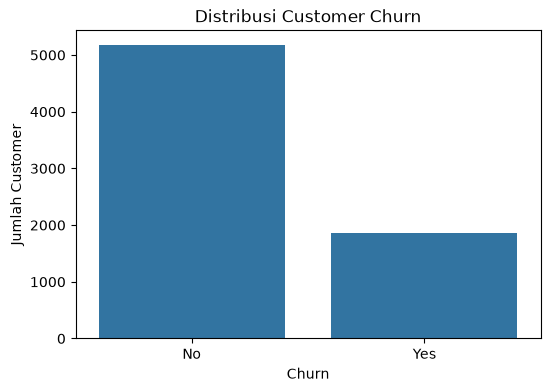

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [596]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="Churn")
plt.title("Distribusi Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Customer")
plt.show()

print(data["Churn"].value_counts())
print("\nPersentase:")
print(data["Churn"].value_counts(normalize=True) * 100)

In [597]:
kolom_numerik = ["tenure", "MonthlyCharges", "TotalCharges"]
kolom_id = ["customerID"]
kolom_kategorikal = [kolom for kolom in data.columns if kolom not in kolom_numerik]

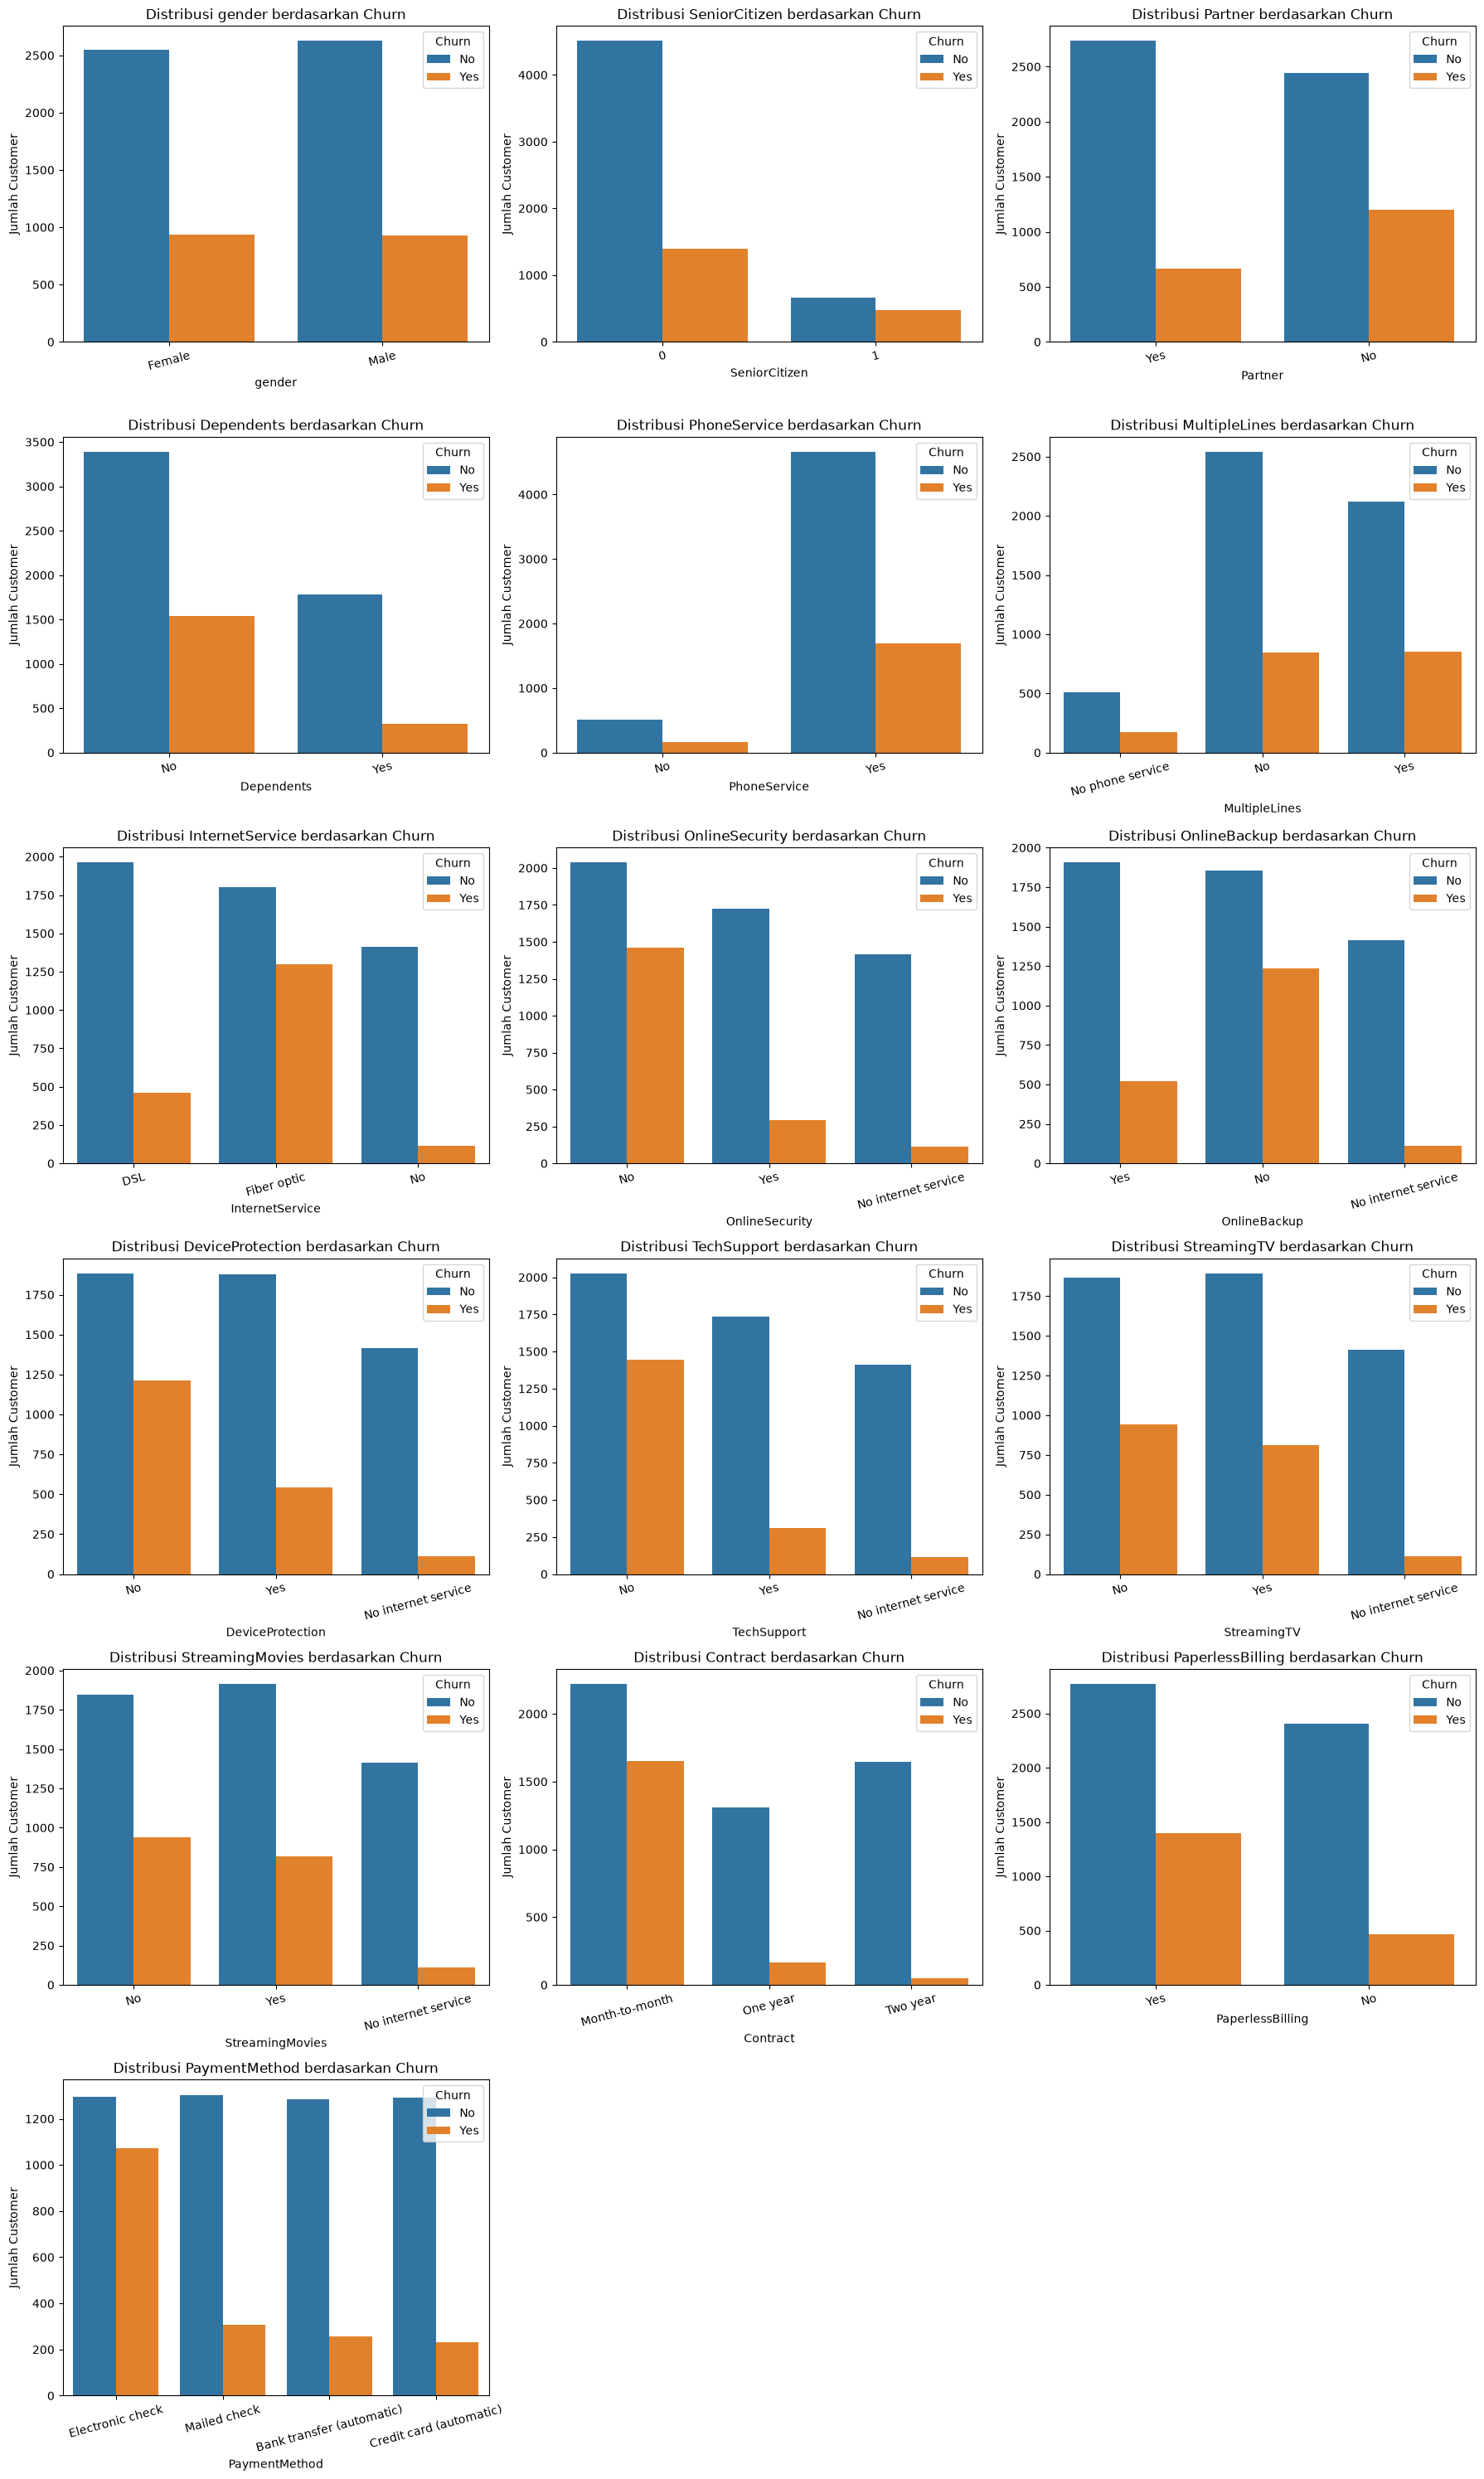

In [598]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
fitur_kategorikal = [
    kolom for kolom in kolom_kategorikal
    if kolom not in ["Churn", *kolom_id]
]

n = len(fitur_kategorikal)
n_cols = 3
n_rows = math.ceil(n / n_cols)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)
axes = axes.flatten()
for i, kolom in enumerate(fitur_kategorikal):
    sns.countplot(
        data=data,
        x=kolom,
        hue="Churn",
        ax=axes[i]
    )
    axes[i].set_title(f"Distribusi {kolom} berdasarkan Churn")
    axes[i].set_xlabel(kolom)
    axes[i].set_ylabel("Jumlah Customer")
    axes[i].tick_params(axis="x", rotation=15)
for i in range(n, len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

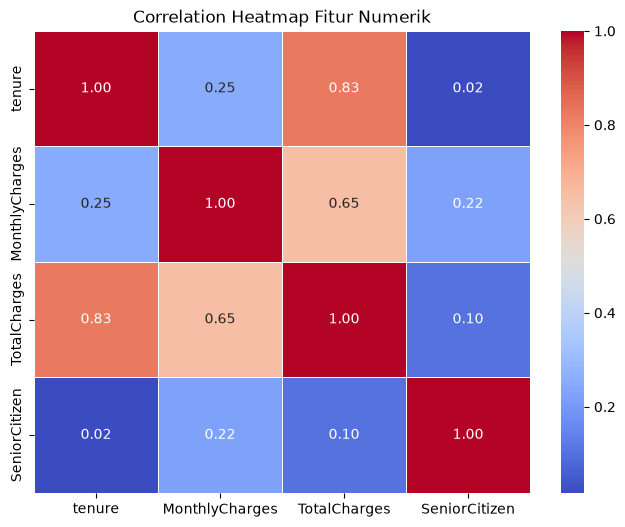

In [599]:
plt.figure(figsize=(8, 6))
corr = data[kolom_numerik + ["SeniorCitizen"]].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap Fitur Numerik")
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [600]:
X = data.drop(columns=["Churn"])
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

median_totalcharges = X_train["TotalCharges"].median()

X_train["TotalCharges"] = X_train["TotalCharges"].fillna(median_totalcharges)
X_test["TotalCharges"] = X_test["TotalCharges"].fillna(median_totalcharges)

In [601]:
fitur_kategorikal = [
    kolom for kolom in X_train.select_dtypes(exclude="number").columns
    if kolom not in kolom_id
]

fitur_numerik = X_train.select_dtypes(include="number").columns.tolist()

print("Fitur kategorikal:")
print(fitur_kategorikal)

print("\nFitur numerik:")
print(fitur_numerik)

Fitur kategorikal:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Fitur numerik:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [602]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(
    X_train[fitur_kategorikal]
)

X_test_encoded = encoder.transform(
    X_test[fitur_kategorikal]
)

In [603]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(fitur_kategorikal),
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(fitur_kategorikal),
    index=X_test.index
)

X_train_final = pd.concat(
    [X_train[fitur_numerik], X_train_encoded],
    axis=1
)

X_test_final = pd.concat(
    [X_test[fitur_numerik], X_test_encoded],
    axis=1
)

print("Ukuran X_train:", X_train_final.shape)
print("Ukuran X_test :", X_test_final.shape)

Ukuran X_train: (5634, 45)
Ukuran X_test : (1409, 45)


In [604]:
y_train = y_train.map({
    "No": 0,
    "Yes": 1
})

y_test = y_test.map({
    "No": 0,
    "Yes": 1
})

**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [605]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()

X_train_scaled = X_train_final.copy()
X_test_scaled = X_test_final.copy()

X_train_scaled[kolom_numerik] = scaler.fit_transform(X_train_final[kolom_numerik])
X_test_scaled[kolom_numerik] = scaler.transform(X_test_final[kolom_numerik])

print("Ukuran X_train setelah scaling:", X_train_scaled.shape)
print("Ukuran X_test setelah scaling :", X_test_scaled.shape)

Ukuran X_train setelah scaling: (5634, 45)
Ukuran X_test setelah scaling : (1409, 45)


In [606]:
print("Contoh hasil scaling:")
display(X_train_scaled.head())

Contoh hasil scaling:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0.102371,-0.521976,-0.263290,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3151,0,-0.711743,0.337478,-0.504815,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4860,0,-0.793155,-0.809013,-0.751214,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3867,0,-0.263980,0.284384,-0.173700,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3810,0,-1.281624,-0.676279,-0.990851,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [607]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    random_state=42,
    max_iter=500
)

model.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [608]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred = model.predict(X_test_scaled)

print("Hasil prediksi:")
print(y_pred[:10])

Hasil prediksi:
[0 1 0 0 0 1 0 0 0 0]


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [609]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
hidden_layer_sizes = (10,)
max_iter = 500
random_state = 42

model_relu = MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes,
    activation="relu",
    max_iter=max_iter,
    random_state=random_state
)

model_tanh = MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes,
    activation="tanh",
    max_iter=max_iter,
    random_state=random_state
)

model_logistic = MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes,
    activation="logistic",
    max_iter=max_iter,
    random_state=random_state
)

models = {
    "relu": model_relu,
    "tanh": model_tanh,
    "logistic": model_logistic
}

for activation, m in models.items():
    m.fit(X_train_scaled, y_train)

In [610]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.
hasil_akurasi = []

for activation, m in models.items():
    y_pred_act = m.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred_act)
    
    hasil_akurasi.append({
        "Activation": activation,
        "Accuracy": accuracy
    })

tabel_akurasi = pd.DataFrame(hasil_akurasi)

tabel_akurasi["Accuracy"] = tabel_akurasi["Accuracy"] * 100

display(tabel_akurasi)

,Activation,Accuracy
0,relu,79.276082
1,tanh,77.998581
2,logistic,80.056778


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [611]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
best_activation = tabel_akurasi.loc[tabel_akurasi["Accuracy"].idxmax(), "Activation"]
print("Activation terbaik dari eksperimen 3.2:", best_activation)


hidden_layer_variations = [
    (2,),
    (5,),
    (10,),
    (50,),
    (100, 50)
]

models_hidden = {}

for hidden_layers in hidden_layer_variations:
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=best_activation,
        max_iter=500,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    models_hidden[hidden_layers] = model

Activation terbaik dari eksperimen 3.2: logistic


c:\Users\Jordan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [612]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
hasil_hidden = []

for hidden_layers, model in models_hidden.items():
    y_train_pred = model.predict(X_train_scaled)
    
    y_test_pred = model.predict(X_test_scaled)
    
    train_accuracy = accuracy_score(y_train, y_train_pred) * 100
    test_accuracy = accuracy_score(y_test, y_test_pred) * 100
    
    hasil_hidden.append({
        "Hidden Layer": str(hidden_layers),
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

hasil_hidden_df = pd.DataFrame(hasil_hidden)

display(hasil_hidden_df)

,Hidden Layer,Train Accuracy,Test Accuracy
0,"(2,)",80.546681,80.127750
1,"(5,)",80.546681,79.701916
2,"(10,)",80.848420,80.056778
3,"(50,)",80.724175,80.340667
4,"(100, 50)",82.818601,77.856636


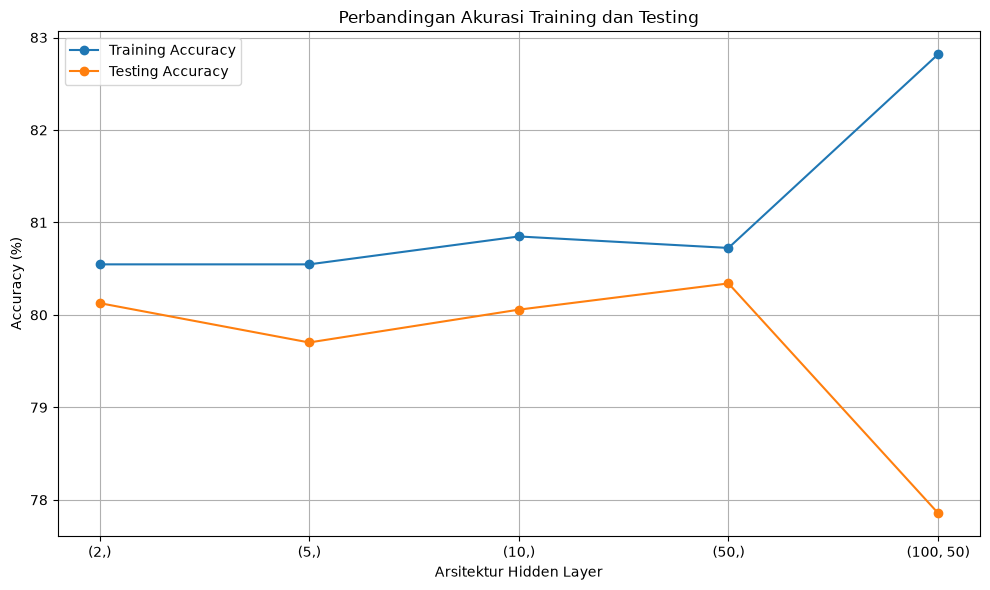

In [613]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(10, 6))

plt.plot(
    hasil_hidden_df["Hidden Layer"],
    hasil_hidden_df["Train Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    hasil_hidden_df["Hidden Layer"],
    hasil_hidden_df["Test Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.title("Perbandingan Akurasi Training dan Testing")
plt.xlabel("Arsitektur Hidden Layer")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [614]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
best_activation = tabel_akurasi.loc[
    tabel_akurasi["Accuracy"].idxmax(), "Activation"
]

model_terbaik_32 = models[best_activation]

y_pred_32 = model_terbaik_32.predict(X_test_scaled)


best_hidden = hasil_hidden_df.loc[
    hasil_hidden_df["Test Accuracy"].idxmax(), "Hidden Layer"
]

best_hidden_tuple = next(
    key for key in models_hidden.keys()
    if str(key) == best_hidden
)

model_terbaik_33 = models_hidden[best_hidden_tuple]

y_pred_33 = model_terbaik_33.predict(X_test_scaled)



hasil_evaluasi = []

for eksperimen, model_name, y_pred in [
    ("3.2", f"Activation = {best_activation}", y_pred_32),
    ("3.3", f"Hidden Layer = {best_hidden}", y_pred_33)
]:
    hasil_evaluasi.append({
        "Eksperimen": eksperimen,
        "Model Terbaik": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })


tabel_evaluasi = pd.DataFrame(hasil_evaluasi)

kolom_metrik = ["Accuracy", "Precision", "Recall", "F1-Score"]
tabel_evaluasi[kolom_metrik] *= 100

display(tabel_evaluasi.round(2))

,Eksperimen,Model Terbaik,Accuracy,Precision,Recall,F1-Score
0,3.2,Activation = logistic,80.06,65.15,53.48,58.74
1,3.3,"Hidden Layer = (50,)",80.34,65.11,55.88,60.14


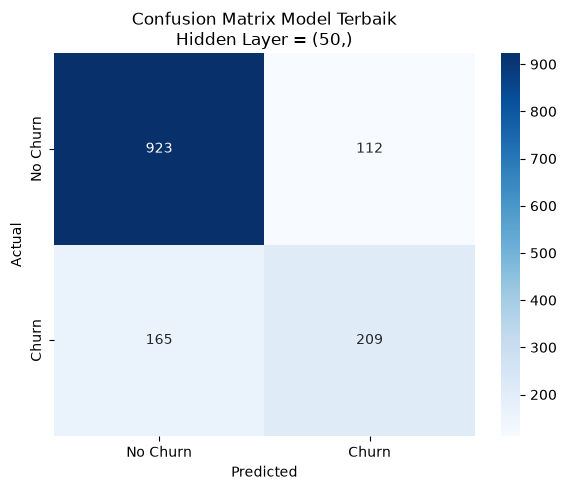

In [ ]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
best_hidden = hasil_hidden_df.loc[
    hasil_hidden_df["Test Accuracy"].idxmax(), "Hidden Layer"
]

best_hidden_tuple = next(
    key for key in models_hidden.keys()
    if str(key) == best_hidden
)

model_terbaik = models_hidden[best_hidden_tuple]

y_pred_best = model_terbaik.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title(f"Confusion Matrix Model Terbaik\nHidden Layer = {best_hidden}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

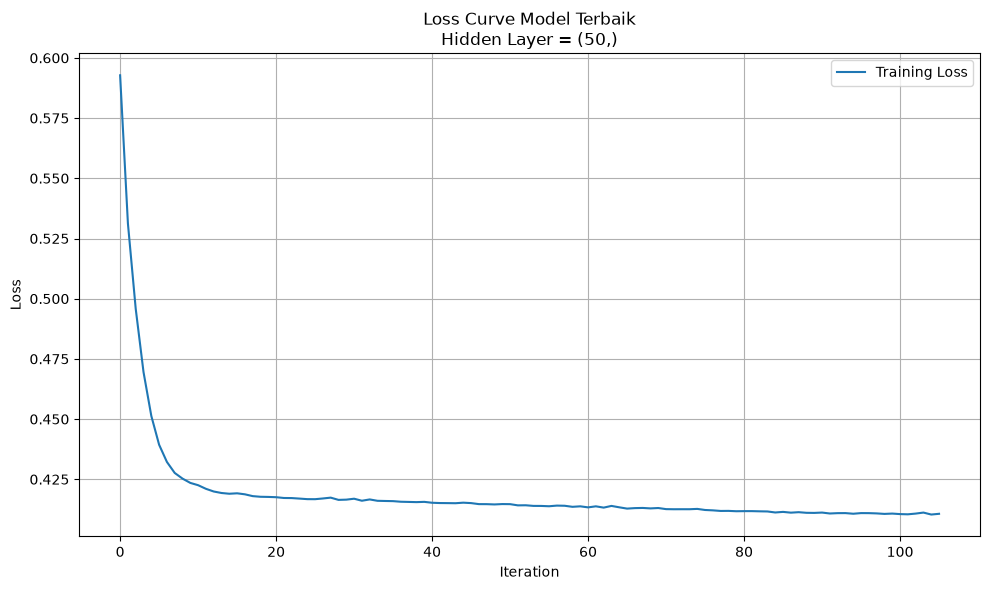

In [617]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
best_hidden = hasil_hidden_df.loc[
    hasil_hidden_df["Test Accuracy"].idxmax(), "Hidden Layer"
]

best_hidden_tuple = next(
    key for key in models_hidden.keys()
    if str(key) == best_hidden
)

model_terbaik = models_hidden[best_hidden_tuple]

plt.figure(figsize=(10, 6))

plt.plot(
    model_terbaik.loss_curve_,
    label="Training Loss"
)

plt.title(f"Loss Curve Model Terbaik\nHidden Layer = {best_hidden}")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

# Analisis Hasil Eksperimen Neural Network (MLPClassifier)

Dataset: Telco Customer Churn (7.043 data). Data uji berjumlah 1.409 sampel, sehingga **1 sampel ≈ 0,07%** dan selisih 1% setara sekitar 14 sampel. Kelas mayoritas (*No Churn*) berjumlah 73,46%, jadi akurasi di atas angka tersebut baru berarti model belajar sesuatu.

## 1. Perbandingan Fungsi Aktivasi (ReLU, Tanh, dan Logistic)

| Fungsi Aktivasi | Akurasi Testing (%) | Jumlah Iterasi | Final Loss |
| :--- | :---: | :---: | :---: |
| **Logistic (Sigmoid)** | **80,06** | 174 | 0,4069 |
| ReLU | 79,28 | 291 | 0,3923 |
| Tanh | 78,00 | 401 | 0,3798 |

*(Arsitektur sama `(10,)`, `max_iter=500`, `random_state=42`.)*

### Analisis

- **Signifikansi hasil:** Perbedaan antar fungsi aktivasi **kecil**, yaitu 78,00%–80,06%. Logistic vs ReLU hanya berbeda sekitar 11 sampel dari 1.409, dan Logistic vs Tanh sekitar 29 sampel. Karena hanya dijalankan dengan satu `random_state` dan satu split data, selisih sekecil ini **belum bisa disimpulkan sebagai perbedaan yang nyata**. Pada satu pembagian data yang digunakan dalam eksperimen ini, ketiga fungsi aktivasi menghasilkan performa yang relatif berdekatan, sehingga belum terdapat bukti yang cukup untuk menyatakan adanya perbedaan performa yang konsisten.
- **Pola yang menarik:** Urutan final loss training berkebalikan dengan urutan akurasi test. Tanh menghasilkan training loss paling rendah, tetapi akurasi testing paling rendah. Hal ini menunjukkan bahwa hasil optimasi pada data training tidak selalu menghasilkan generalisasi terbaik pada data testing, walaupun dengan satu kali percobaan hal ini belum bisa dipastikan.
- **Kemungkinan penjelasan:**
  1. Dengan satu hidden layer yang dangkal dan fitur yang sudah di-*scale*, ketiga fungsi aktivasi mampu mempelajari pola yang kurang lebih sama. Ini wajar karena pada eksperimen ini, perubahan ukuran hidden layer dari (2,) hingga (50,) menghasilkan performa yang relatif mirip, sehingga peningkatan kapasitas model pada rentang tersebut belum memberikan peningkatan generalisasi yang berarti.
  2. Perbedaan jumlah iterasi (174 vs 291 vs 401) menunjukkan karakter optimasi yang berbeda. Logistic berhenti paling cepat karena perbaikan loss-nya lebih cepat melambat, bukan karena modelnya otomatis lebih baik.
  3. Selisih kecil seperti ini juga bisa berasal dari inisialisasi bobot acak. Untuk memastikannya, perlu pengulangan dengan beberapa `random_state` atau *cross-validation*.
- **Catatan konsep:** Parameter `activation` pada `MLPClassifier` hanya mengatur fungsi aktivasi di **hidden layer**. Layer output untuk klasifikasi biner selalu memakai sigmoid, apa pun pilihan `activation`. Karena itu, keunggulan Logistic **tidak dapat dijelaskan** dengan alasan bahwa outputnya cocok untuk probabilitas biner.

---

## 2. Eksperimen Arsitektur (`hidden_layer_sizes`) dan Overfitting

*(Memakai aktivasi `logistic`, hasil terbaik dari eksperimen 3.2.)*

| Arsitektur Hidden Layer | Train Accuracy (%) | Test Accuracy (%) | Selisih (Train − Test) | Status |
| :---: | :---: | :---: | :---: | :---: |
| `(2,)` | 80,55 | 80,13 | 0,42 | Tidak ada indikasi overfitting |
| `(5,)` | 80,55 | 79,70 | 0,85 | Tidak ada indikasi overfitting |
| `(10,)` | 80,85 | 80,06 | 0,79 | Tidak ada indikasi overfitting |
| `(50,)` | 80,72 | 80,34 | 0,38 | Test accuracy tertinggi |
| `(100, 50)` | 82,82 | 77,86 | 4,96 | **Indikasi overfitting** |

### Analisis Overfitting

- **Arsitektur `(2,)` sampai `(50,)`:** Akurasi training dan testing berada di kisaran 80% dengan selisih di bawah 1%. Test accuracy `(50,)` (80,34%) hanya unggul sekitar 3 sampel dari `(2,)` (80,13%). Jadi menambah neuron dari 2 hingga 50 **hampir tidak meningkatkan performa**. Model `(2,)` yang jauh lebih sederhana praktis setara, dan `(50,)` dipilih hanya karena test accuracy-nya paling tinggi.
- **Titik overfitting:** Gejala overfitting terlihat pada arsitektur `(100, 50)`. Perlu dicatat bahwa pada arsitektur ini **lebar dan kedalaman berubah sekaligus**, dan tidak ada arsitektur di antara `(50,)` dan `(100, 50)`. Karena itu notebook ini hanya dapat menyimpulkan bahwa overfitting muncul **di antara `(50,)` dan `(100, 50)`**, bukan menentukan ukuran persisnya.
- **Ciri pada grafik:**
  1. Pada `(2,)` sampai `(50,)`, kurva training dan testing berjalan mendatar dan berdekatan.
  2. Pada `(100, 50)`, kedua kurva **berpisah (divergen)**: akurasi training naik ke 82,82% sementara akurasi testing turun ke 77,86%. Selisihnya melebar dari kurang dari 1% menjadi 4,96%.
- **Penyebab:** Kapasitas model yang jauh lebih besar membuatnya mulai menyesuaikan diri dengan pola khusus (termasuk *noise*) pada data training, sehingga kemampuan generalisasinya menurun.
- **Catatan tambahan:** Model (100,50) belum konvergen pada 500 iterasi. Oleh karena itu, pengaruh penambahan iterasi terhadap generalisasi masih perlu diuji lebih lanjut..

---

## 3. Metrik Evaluasi Model Terbaik (`logistic`, `hidden_layer_sizes=(50,)`)

| Metrik | Nilai (%) |
| :--- | :---: |
| Accuracy | 80,34 |
| Precision | 65,11 |
| Recall | 55,88 |
| F1-Score | 60,14 |

Confusion matrix menunjukkan 923 TN, 112 FP, 165 FN, dan 209 TP. Dari 374 pelanggan yang benar-benar churn, **165 (sekitar 44%) tidak terdeteksi**. Akurasi 80,34% hanya sekitar 7 poin di atas baseline kelas mayoritas (73,46%), sehingga akurasi saja kurang menggambarkan kinerja pada kelas churn. Recall dan F1 lebih informatif untuk kasus ini.

---

## 4. Analisis Loss Curve dan Konvergensi

- **Konvergensi model `(50,)`:**
  - Loss turun tajam pada sekitar 10 iterasi pertama (dari ±0,59 ke ±0,42), lalu melandai sangat pelan sampai sekitar 0,4107.
  - Pelatihan berhenti otomatis pada **iterasi ke-106**, sebelum `max_iter=500`, karena kriteria berhenti sklearn (`tol` dan `n_iter_no_change`) terpenuhi. Jadi model dapat dikatakan **sudah konvergen menurut kriteria sklearn**. Kurvanya masih turun sangat tipis di akhir, tetapi tidak ada penurunan tajam yang tersisa.
  - Arsitektur `(100, 50)` berhenti karena mencapai batas `max_iter=500` dan **belum konvergen**.
- **Jika loss curve masih turun tajam saat `max_iter` tercapai:**
  1. Naikkan `max_iter` (misalnya 1000–2000).
  2. Sesuaikan `learning_rate_init` atau gunakan `learning_rate='adaptive'` (berlaku untuk solver `sgd`).
  3. Aktifkan `early_stopping=True` agar berhenti berdasarkan validation score, bukan hanya training loss.
  4. Pastikan seluruh fitur numerik sudah di-*scale* dan pertimbangkan `alpha` (regularisasi L2) yang lebih besar bila ada tanda overfitting.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

# Kesimpulan dan Saran

## 1. Kesimpulan

- **Pengaruh fungsi aktivasi:** Logistic menghasilkan akurasi pengujian tertinggi (80,06%), disusul ReLU (79,28%) dan Tanh (78,00%). Namun selisihnya kecil (sekitar 11–29 sampel dari 1.409) dan hanya diuji dengan satu seed, sehingga ketiga fungsi aktivasi **dapat dianggap setara pada arsitektur dan dataset ini**.
- **Pengaruh arsitektur dan generalisasi:** Menambah neuron dari `(2,)` sampai `(50,)` hampir tidak mengubah performa (test accuracy 79,70%–80,34%, selisih train–test di bawah 1%). Arsitektur besar `(100, 50)` menunjukkan **indikasi overfitting** (training 82,82% vs testing 77,86%, selisih 4,96%) dan belum konvergen dalam 500 iterasi. Test accuracy tertinggi dicapai `(50,)` sebesar 80,34%, tetapi model yang jauh lebih sederhana seperti `(2,)` memberi hasil hampir sama.
- **Evaluasi model terbaik:** Model `logistic` dengan `(50,)` memperoleh Accuracy 80,34%, Precision 65,11%, Recall 55,88%, dan F1-Score 60,14%. Recall yang lebih rendah dari Precision, dengan 165 dari 374 pelanggan churn tidak terdeteksi, menunjukkan model masih cenderung memprediksi kelas mayoritas (*No Churn*). Hal ini sejalan dengan ketidakseimbangan kelas (26,5% *Yes* vs 73,5% *No*).
- **Keterbatasan:** Pemilihan model terbaik memakai test set dan hanya satu kali split atau seed, tanpa validation set atau cross-validation. Jadi selisih kecil antar model sebaiknya tidak ditafsirkan sebagai perbedaan yang pasti.

## 2. Saran

1. **Evaluasi yang lebih stabil:** Ulangi eksperimen dengan beberapa `random_state` atau *Stratified K-Fold Cross Validation*, dan pilih model berdasarkan validation set, bukan test set.
2. **Hyperparameter tuning:** Gunakan `GridSearchCV` atau `RandomizedSearchCV` untuk `hidden_layer_sizes`, `learning_rate_init`, `alpha`, dan `batch_size`.
3. **Solver lain:** Coba `'sgd'` (dengan momentum) atau `'lbfgs'` sebagai pembanding terhadap `'adam'`.
4. **Regularisasi dan early stopping:** Tambahkan `alpha` (misalnya `1e-3` atau `1e-2`) untuk menekan overfitting pada arsitektur besar, dan aktifkan `early_stopping=True`.
5. **Penanganan class imbalance:** Gunakan `class_weight` pada model pembanding, resampling seperti SMOTE atau *random under-sampling*, atau turunkan *decision threshold* agar Recall dan F1 untuk kelas churn meningkat. Perhatikan bahwa `MLPClassifier` tidak punya parameter `class_weight`, sehingga resampling atau penyesuaian threshold lebih praktis.
6. **Komparasi dengan model lain:** Bandingkan dengan Logistic Regression sebagai baseline sederhana, serta Random Forest, XGBoost, atau LightGBM yang umumnya kompetitif pada data tabular.